<a href="https://colab.research.google.com/github/rithishdev/DL_Lab/blob/main/DL_Exp03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Rithish A - 24BAD099

## PART A: DATASET PREPARATION

### Load the CIFAR-10 Dataset

In [1]:
import tensorflow as tf
from tensorflow.keras.datasets import cifar10

# Load the CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

print(f"x_train shape: {x_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"x_test shape: {x_test.shape}")
print(f"y_test shape: {y_test.shape}")

print(f"Number of training samples: {len(x_train)}")
print(f"Number of test samples: {len(x_test)}")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1472s 9us/step
x_train shape: (50000, 32, 32, 3)
y_train shape: (50000, 1)
x_test shape: (10000, 32, 32, 3)
y_test shape: (10000, 1)
Number of training samples: 50000
Number of test samples: 10000


### Preprocess Images by Normalization and One-Hot Encode Labels

In [2]:
# Normalize pixel values to be between 0 and 1
x_train_normalized = x_train.astype('float32') / 255.0
x_test_normalized = x_test.astype('float32') / 255.0

# One-hot encode the labels
y_train_one_hot = tf.keras.utils.to_categorical(y_train, num_classes=10)
y_test_one_hot = tf.keras.utils.to_categorical(y_test, num_classes=10)

print(f"x_train_normalized shape: {x_train_normalized.shape}")
print(f"y_train_one_hot shape: {y_train_one_hot.shape}")
print(f"x_test_normalized shape: {x_test_normalized.shape}")
print(f"y_test_one_hot shape: {y_test_one_hot.shape}")

x_train_normalized shape: (50000, 32, 32, 3)
y_train_one_hot shape: (50000, 10)
x_test_normalized shape: (10000, 32, 32, 3)
y_test_one_hot shape: (10000, 10)


### Split the Dataset into Training, Validation, and Testing Sets

In [3]:
from sklearn.model_selection import train_test_split

# Split the original training data into training and validation sets
# We'll use 10% of the training data for validation
x_train_final, x_val, y_train_final, y_val = train_test_split(
    x_train_normalized, y_train_one_hot, test_size=0.1, random_state=42
)

print(f"Final training set shapes: {x_train_final.shape}, {y_train_final.shape}")
print(f"Validation set shapes: {x_val.shape}, {y_val.shape}")
print(f"Test set shapes: {x_test_normalized.shape}, {y_test_one_hot.shape}")

Final training set shapes: (45000, 32, 32, 3), (45000, 10)
Validation set shapes: (5000, 32, 32, 3), (5000, 10)
Test set shapes: (10000, 32, 32, 3), (10000, 10)


## PART B: CNN MODEL IMPLEMENTATION

### Build and Compile the CNN Model

In [4]:
from tensorflow.keras import layers, models

# Define the CNN model
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax') # 10 classes for CIFAR-10
])

# Compile the model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

## PART C: MODEL TRAINING AND EVALUATION

### Train the CNN Model

In [5]:
history = model.fit(
    x_train_final, y_train_final,
    epochs=10, # You can adjust the number of epochs
    batch_size=64, # You can adjust the batch size
    validation_data=(x_val, y_val)
)

# Record Training and Validation Metrics
training_accuracy = history.history['accuracy']
validation_accuracy = history.history['val_accuracy']
training_loss = history.history['loss']
validation_loss = history.history['val_loss']

print("\nTraining complete.")
print(f"Final Training Accuracy: {training_accuracy[-1]:.4f}")
print(f"Final Validation Accuracy: {validation_accuracy[-1]:.4f}")
print(f"Final Training Loss: {training_loss[-1]:.4f}")
print(f"Final Validation Loss: {validation_loss[-1]:.4f}")

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 75s 104ms/step - accuracy: 0.4146 - loss: 1.6033 - val_accuracy: 0.4938 - val_loss: 1.3800
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 65s 93ms/step - accuracy: 0.5576 - loss: 1.2467 - val_accuracy: 0.5486 - val_loss: 1.2606
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 63s 90ms/step - accuracy: 0.6126 - loss: 1.0959 - val_accuracy: 0.6260 - val_loss: 1.0630
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 64s 91ms/step - accuracy: 0.6472 - loss: 1.0020 - val_accuracy: 0.6432 - val_loss: 1.0032
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 64s 91ms/step - accuracy: 0.6748 - loss: 0.9283 - val_accuracy: 0.6256 - val_loss: 1.0627
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 63s 89ms/step - accuracy: 0.6932 - loss: 0.8772 - val_accuracy: 0.6666 - val_loss: 0.9447
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 89ms/step - accuracy: 0.7080 - loss: 0.8296 - val_accuracy: 0.6696 - val_loss: 0.9360
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 63s 90ms/step - accuracy: 0.7254 - loss: 0.7831 -

### Plot Accuracy vs Epoch and Loss vs Epoch

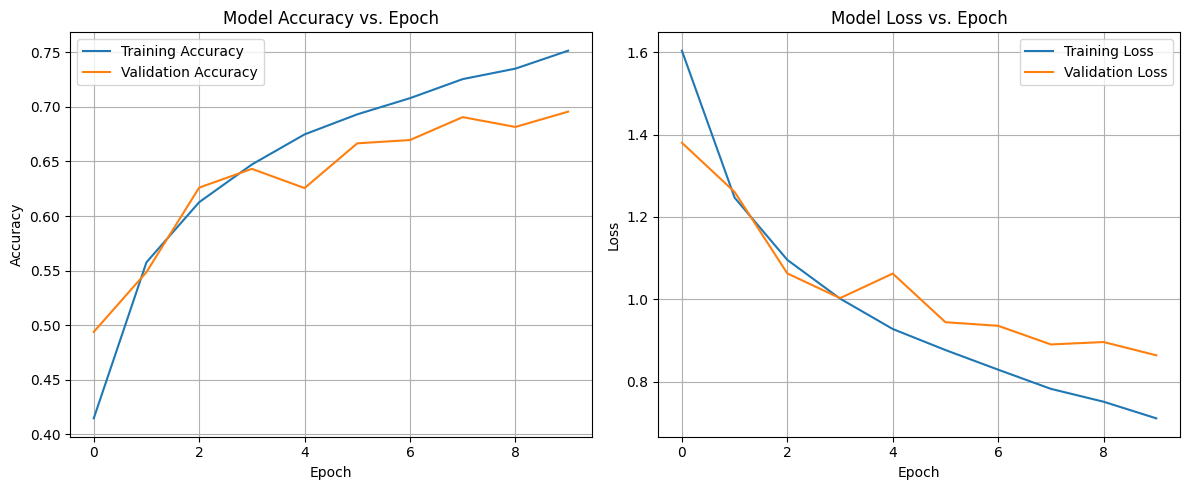

In [6]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy vs. Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss vs. Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Evaluate Testing Accuracy

In [7]:
test_loss, test_accuracy = model.evaluate(x_test_normalized, y_test_one_hot, verbose=2)

print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

313/313 - 5s - 15ms/step - accuracy: 0.6975 - loss: 0.8842

Test Loss: 0.8842
Test Accuracy: 0.6975


## PART D: PERFORMANCE ANALYSIS

### Analyze Classification Accuracy with Confusion Matrix

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step


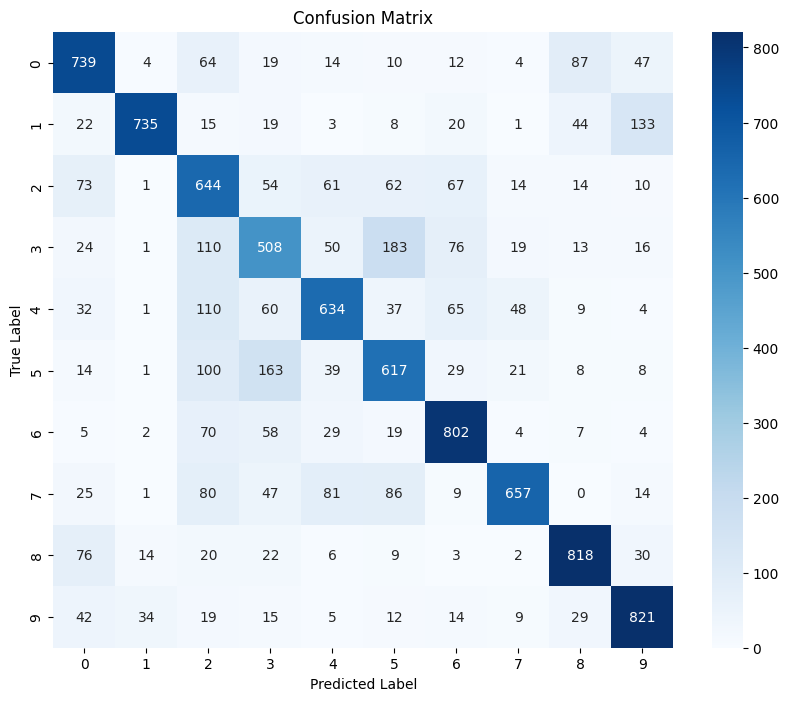


Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.74      0.72      1000
           1       0.93      0.73      0.82      1000
           2       0.52      0.64      0.58      1000
           3       0.53      0.51      0.52      1000
           4       0.69      0.63      0.66      1000
           5       0.59      0.62      0.60      1000
           6       0.73      0.80      0.76      1000
           7       0.84      0.66      0.74      1000
           8       0.79      0.82      0.81      1000
           9       0.76      0.82      0.79      1000

    accuracy                           0.70     10000
   macro avg       0.71      0.70      0.70     10000
weighted avg       0.71      0.70      0.70     10000



In [8]:
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Get predictions for the test set
y_pred_probs = model.predict(x_test_normalized)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test_one_hot, axis=1)

# Generate Confusion Matrix
conf_matrix = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# Print Classification Report
print('\nClassification Report:')
print(classification_report(y_true, y_pred))

### Visualize Sample Predictions

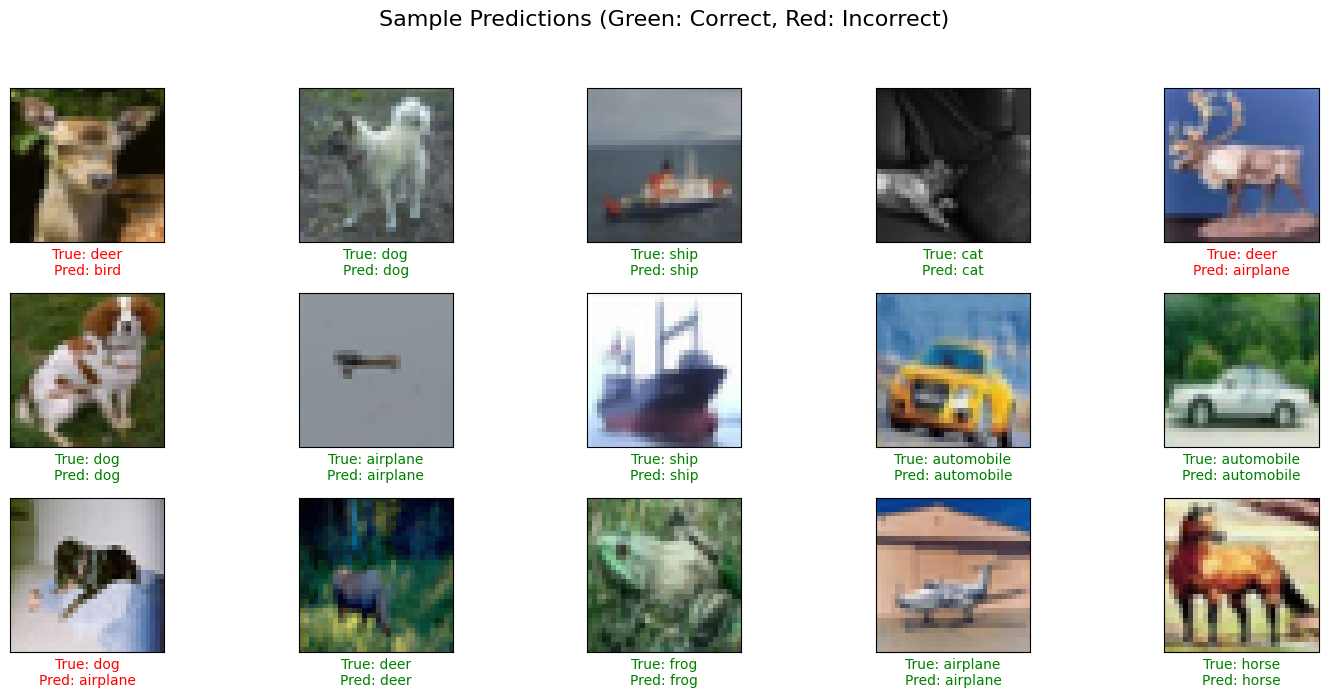

In [9]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

plt.figure(figsize=(15, 7))
for i in range(15): # Display 15 random test images with predictions
    plt.subplot(3, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    img_index = np.random.randint(0, len(x_test_normalized))
    plt.imshow(x_test_normalized[img_index])

    true_label = class_names[y_true[img_index]]
    predicted_label = class_names[y_pred[img_index]]

    color = 'green' if true_label == predicted_label else 'red'
    plt.xlabel(f"True: {true_label}\nPred: {predicted_label}", color=color)
plt.suptitle('Sample Predictions (Green: Correct, Red: Incorrect)', y=1.02, fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

### Identify and Display Misclassified Images

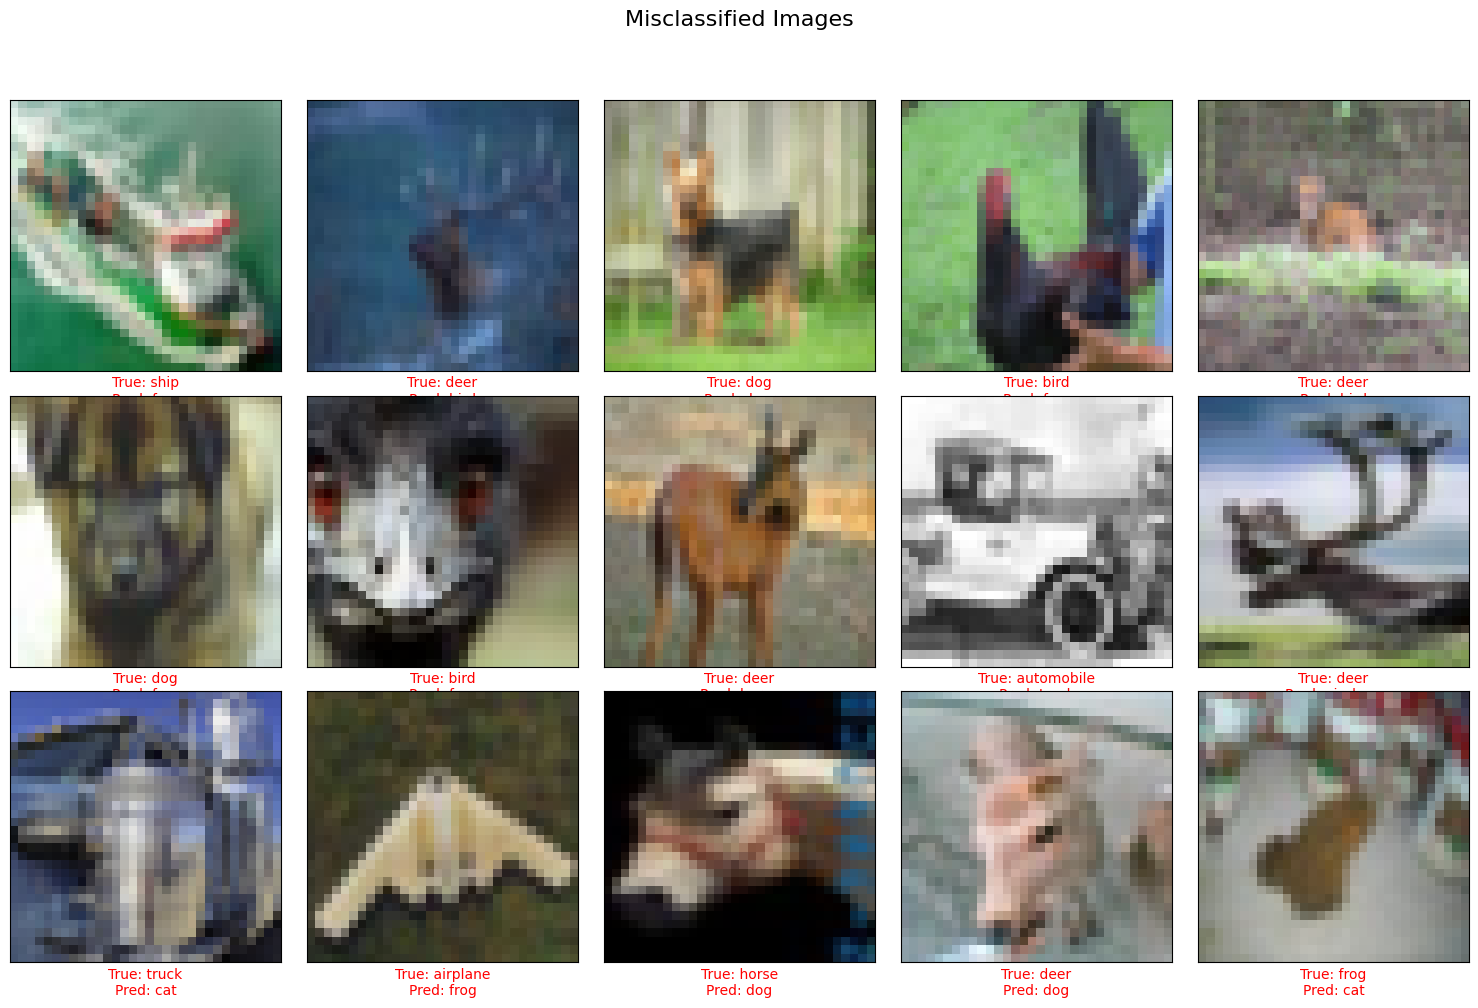

In [10]:
misclassified_indices = np.where(y_true != y_pred)[0]

plt.figure(figsize=(15, 10))
plt.suptitle('Misclassified Images', y=1.02, fontsize=16)
for i in range(min(15, len(misclassified_indices))): # Display up to 15 misclassified images
    plt.subplot(3, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)

    idx = misclassified_indices[i]
    plt.imshow(x_test_normalized[idx])

    true_label = class_names[y_true[idx]]
    predicted_label = class_names[y_pred[idx]]

    plt.xlabel(f"True: {true_label}\nPred: {predicted_label}", color='red')
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()